In [147]:
%pip install h5py
%pip install numpy
%pip install pandas
%pip install seaborn
%pip install matplotlib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import h5py
import numpy as np
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
import os


In [2]:
# DIRECTORY PATHS
curr_dir = os.getcwd()
base_dir = os.path.dirname(curr_dir)
arena_data_dir = os.path.join(base_dir, 'data')
arena_visualizations_dir = os.path.join( base_dir , '3D_Visualizations')
motif_results_dir = os.path.join(arena_visualizations_dir, 'motif_results')

In [3]:
# CONSTANTS

top_n = 40 # the top shown
collapse_repetitions = True
sort_by = 'frequency' # 'frequency' or 'dwell'
n_range = (2,4) # size of motifs from n_start -> n_end
cluster_results = os.path.join(arena_data_dir, "Cluster_detail_results.csv")

In [4]:
df = pd.read_csv(cluster_results)
df.loc[(df['Folder_Name'] == 1), 'Folder_Name'] = 'week8'
df.loc[(df['Folder_Name'] == 2), 'Folder_Name'] = 'week10'
df.loc[df['Folder_Name'] == 3, 'Folder_Name'] = 'week12'
df.loc[(df['Folder_Name'] == 4) | (df['Folder_Name'] == 5), 'Folder_Name'] = 'week14'
df.loc[(df['Folder_Name'] == 6) | (df['Folder_Name'] == 7), 'Folder_Name'] = 'week18'
df['Folder_Name'] = df['Folder_Name'].ffill()

if collapse_repetitions:
    df = df[df["ClusterIdx"].shift() != df["ClusterIdx"]].reset_index(drop=True)
idx_ts = df.iloc[:, :3].to_numpy()

idx_ts

C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_27068\2433949583.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'week8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[(df['Folder_Name'] == 1), 'Folder_Name'] = 'week8'


array([[1, 8414.3922, 'week8'],
       [2, 8416.194, 'week8'],
       [1, 8416.4942, 'week8'],
       ...,
       [87, 49787.5498, 'week18'],
       [50, 49787.8948, 'week18'],
       [19, 49788.2598, 'week18']], shape=(108792, 3), dtype=object)

In [5]:

def extract_motifs(arr, n=2):
    motifs = []
    clusters = arr[:, 0]  # first column = cluster numbers
    times = arr[:, 1]                  # second column = timestamps
    labels = arr[:, 2]                 # third column = labels (e.g. str or int)

    for i in range(len(clusters) - n):
        motif_clusters = clusters[i:i+n]
        motif_labels = labels[i:i+n]

        if pd.isna(motif_clusters).any():
            continue  
        # Check if all labels in this motif are the same
        if len(set(motif_labels)) != 1:
            continue  # skip motifs with mixed labels

        motif = tuple(motif_clusters)
        label = motif_labels[0]  # all are the same by check above

        # process label ----------------------------------------------------!!!!!!!!!!!!!!!!!!!!!!!!!!! MAY NEED TO CHANGE
        try:
            label = label[label.find("_") + 1:]
            if label.find("_") != -1:
                label = label[:label.find("_")]
        except AttributeError:
            print(label)
            continue
        

        start = times[i]
        end = times[i+n]  # end when last cluster in motif ends
        
        dwell = end - start

        if dwell > 200:
            print("Long dwell time detected:", motif, dwell, label)
            print(start, end)
            print("\n")

        motifs.append((motif, dwell, label))
    return motifs

In [6]:
# Extract n-grams
all_motifs = []
for n in range(n_range[0], n_range[1]+1):
    all_motifs += extract_motifs(idx_ts, n=n)

# Aggregate frequencies and dwell times, grouped by motif & label
motif_stats = defaultdict(lambda: {"count": 0, "dwell": 0.0})
for motif, dwell, label in all_motifs:
    key = (motif, label)
    motif_stats[key]["count"] += 1
    motif_stats[key]["dwell"] += dwell

# Build DataFrame
df = pd.DataFrame([
    {
        "motif": "→".join(map(str, motif)),
        "label": label,
        "frequency": stats["count"],
        "dwell_time_adj": stats["dwell"]
    }
    for (motif, label), stats in motif_stats.items()
])

# Count motif length
df["motif_length"] = df["motif"].apply(lambda x: x.count("→") + 1)

# Add average dwell time
df["avg_dwell"] = df["dwell_time_adj"] / df["frequency"]

df["frequency_across_stages"] = df.groupby("motif")["frequency"].transform("sum")
df["dwell_time_across_stages"] = df.groupby("motif")["dwell_time_adj"].transform("sum")
df["avg_dwell_across_stages"] = df["dwell_time_across_stages"] / df["frequency_across_stages"]


Long dwell time detected: (84, 104) 229.66500000000087 week18
47452.3398 47682.0048


Long dwell time detected: (104, 61) 229.68499999999767 week18
47452.6848 47682.3698


Long dwell time detected: (104, 84, 104) 238.4250000000029 week18
47443.5798 47682.0048


Long dwell time detected: (84, 104, 61) 230.02999999999884 week18
47452.3398 47682.3698


Long dwell time detected: (104, 61, 84) 230.375 week18
47452.6848 47683.0598


Long dwell time detected: (103, 104, 84, 104) 239.11500000000524 week18
47442.8898 47682.0048


Long dwell time detected: (104, 84, 104, 61) 238.79000000000087 week18
47443.5798 47682.3698


Long dwell time detected: (84, 104, 61, 84) 230.72000000000116 week18
47452.3398 47683.0598


Long dwell time detected: (104, 61, 84, 4) 230.8050000000003 week18
47452.6848 47683.4898




In [7]:
# Get Maximum of graph to be consistent across plots
max_freq = df['frequency_across_stages'].max()
motif_maxes = {}
for n in range(n_range[0], n_range[1]+1):
    subset = df[df['motif_length'] == n]
    motif_maxes[n] = {
        "y_max": subset['frequency_across_stages'].max() * 1.1,
        "y_max_sub": subset['frequency'].max() * 1.1,
        "dwell_min": subset['dwell_time_adj'].min(),
        "dwell_max": subset['dwell_time_adj'].max(),
        "avg_dwell_min": subset['avg_dwell'].min(),
        "avg_dwell_max": subset['avg_dwell'].max()
    }

In [8]:
# FILTER / SORT

primarySort = ''
secondarySort = ''
if sort_by == 'frequency':
    primarySort = 'frequency_across_stages'
    secondarySort = 'dwell_time_across_stages'
elif sort_by == 'dwell':
    secondarySort = 'frequency_across_stages'
    primarySort = 'dwell_time_across_stages'

df_sorted = df

# sorting
if primarySort and secondarySort:
    df_sorted = df_sorted.sort_values(by=[primarySort, secondarySort], ascending=[False, False])
# Take
# if top_n > 0:
#     top = df_sorted.head(top_n) 

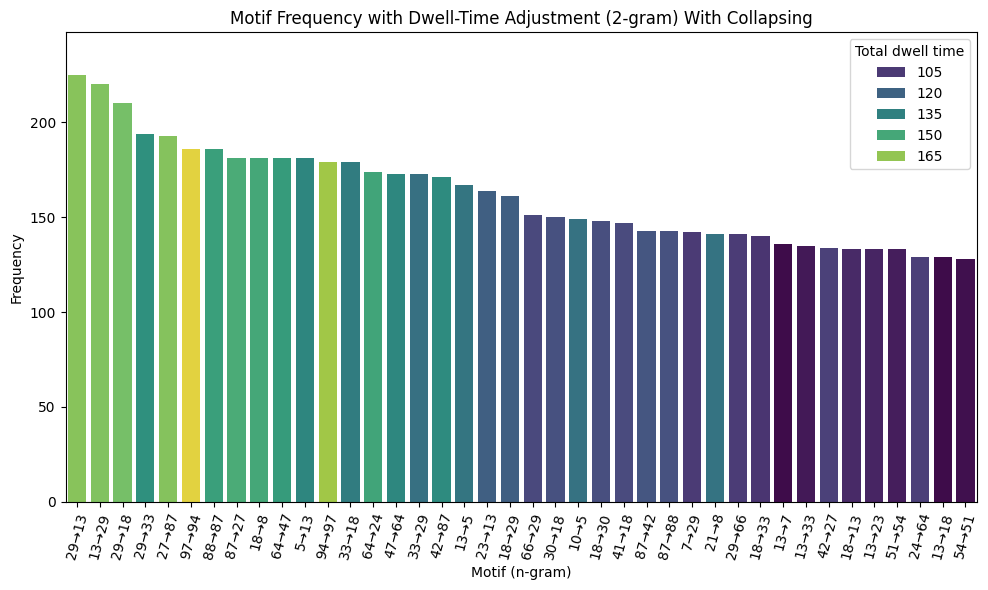

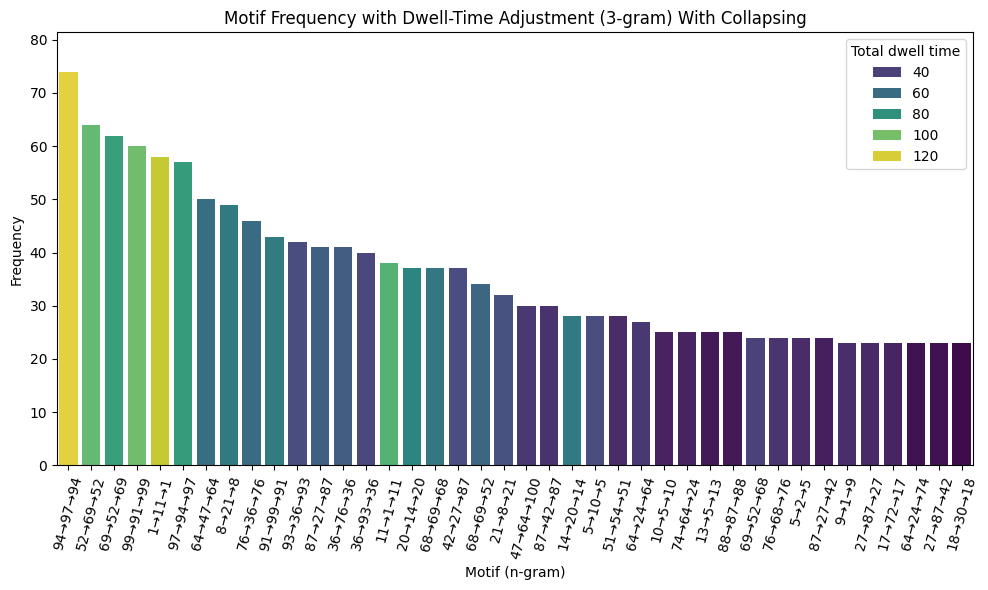

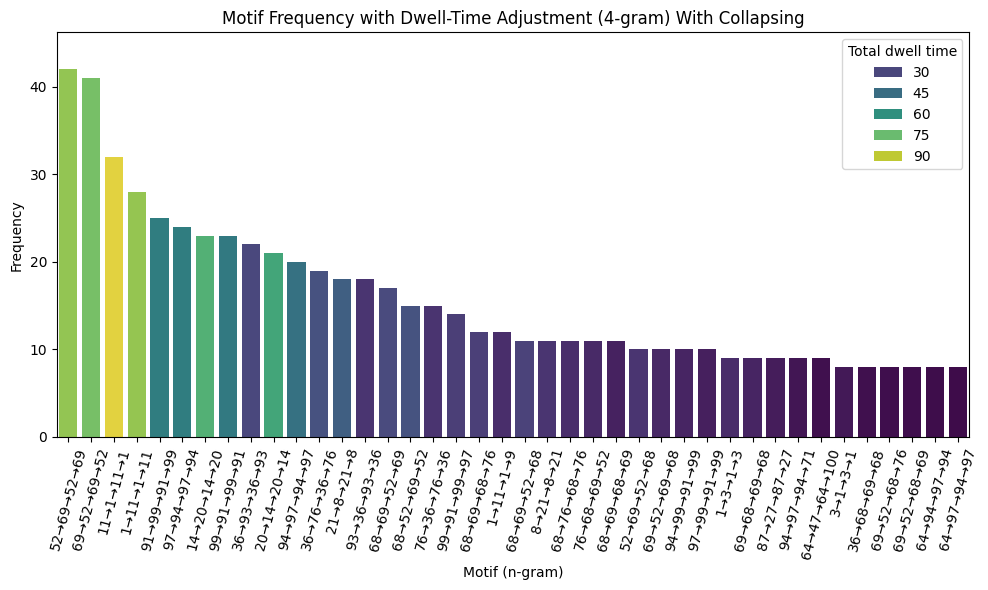

In [9]:
# plt.figure(figsize=(10,6))
# sns.barplot(x="motif", y="frequency", hue="dwell_time_adj", data=top, dodge=False, palette="viridis")

# title = "Motif Frequency with Dwell-Time Adjustment"
# if collapse_repetitions: 
#     title += " With Collapsing"
# else:
#     title += " Without Collapsing"



# plt.title(title)
# plt.xlabel("Motif (n-gram)")
# plt.ylabel("Frequency")
# plt.xticks(rotation=45)
# plt.legend(title="Total dwell time")
# plt.tight_layout()
# plt.show()

df_total = df_sorted.drop_duplicates(subset="motif", keep="first")
# Loop through each unique arrow count and plot separately
for motif_length in sorted(df_total["motif_length"].unique()):
    subset = df_total[df_total["motif_length"] == motif_length]
    top = subset.head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="motif",
        y="frequency_across_stages",
        hue="dwell_time_across_stages",
        data=top,
        dodge=False,
        palette="viridis"
    )
    plt.ylim(0, motif_maxes[motif_length]["y_max"])

    title = f"Motif Frequency with Dwell-Time Adjustment ({motif_length}-gram)"
    if collapse_repetitions:
        title += " With Collapsing"
    else:
        title += " Without Collapsing"

    plt.title(title)
    plt.xlabel("Motif (n-gram)")
    plt.ylabel("Frequency")
    plt.xticks(rotation=75)
    plt.legend(title="Total dwell time")
    plt.tight_layout()
    
    filename = os.path.join(motif_results_dir, f"{motif_length}-gram", f"total_stage_freq_vs_total-dwell.png")
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=300)

    plt.show()

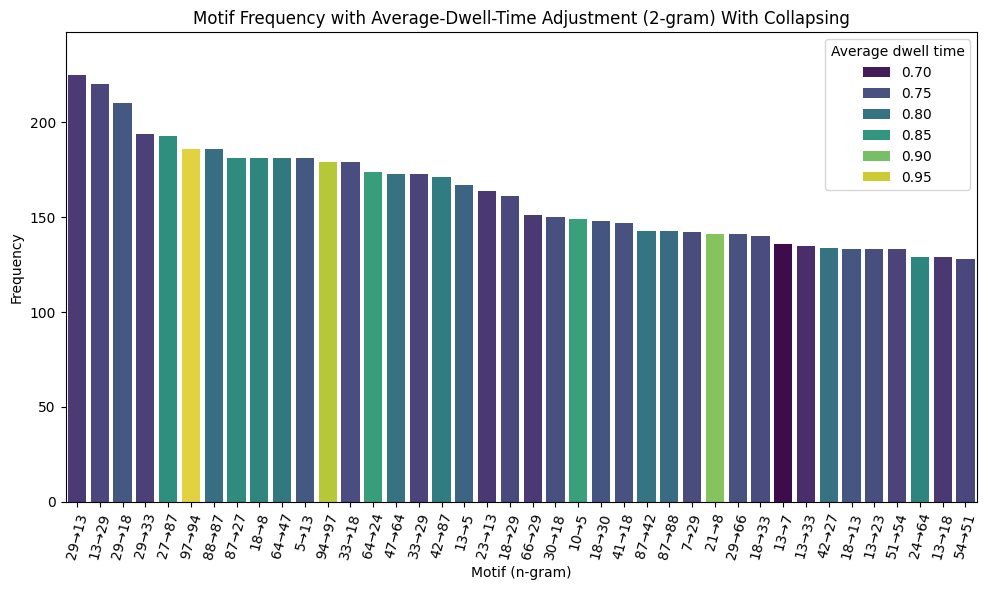

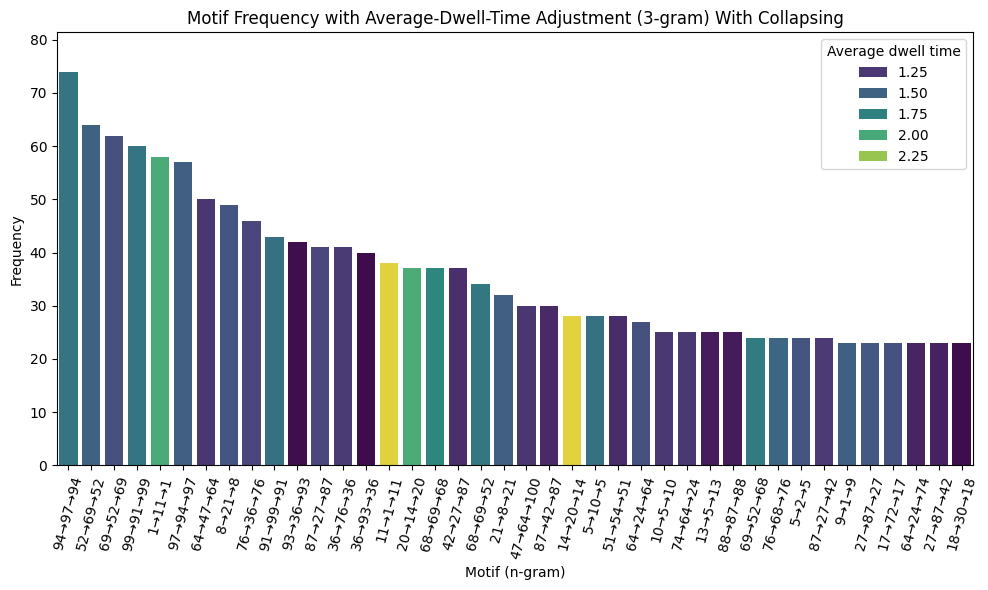

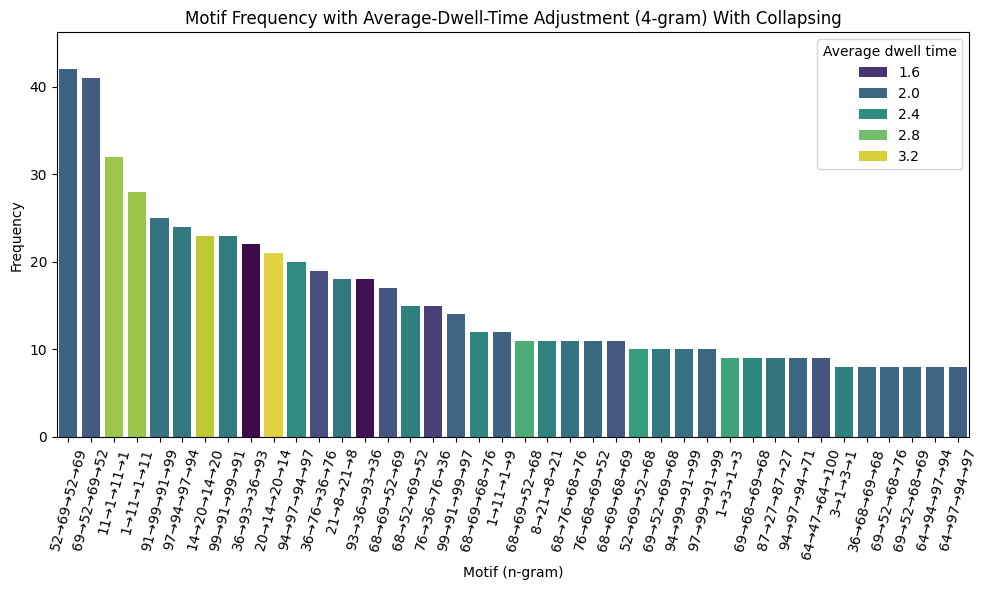

In [10]:
for motif_length in sorted(df_total["motif_length"].unique()):
    subset = df_total[df_total["motif_length"] == motif_length]
    top = subset.head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="motif",
        y="frequency_across_stages",
        hue="avg_dwell_across_stages",
        data=top,
        dodge=False,
        palette="viridis"
    )
    plt.ylim(0, motif_maxes[motif_length]["y_max"])

    title = f"Motif Frequency with Average-Dwell-Time Adjustment ({motif_length}-gram)"
    if collapse_repetitions:
        title += " With Collapsing"
    else:
        title += " Without Collapsing"

    plt.title(title)
    plt.xlabel("Motif (n-gram)")
    plt.ylabel("Frequency")
    plt.xticks(rotation=75)
    plt.legend(title="Average dwell time")
    plt.tight_layout()

    filename = os.path.join(motif_results_dir, f"{motif_length}-gram", f"total_stage_freq_vs_avg-dwell.png")
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=300)

    plt.show()

In [11]:
# FILTER / SORT

primarySort = ''
secondarySort = ''
if sort_by == 'frequency':
    primarySort = 'frequency'
    secondarySort = 'dwell_time_adj'
elif sort_by == 'dwell':
    secondarySort = 'frequency'
    primarySort = 'dwell_time_adj'

df_sorted = df

# sorting
if primarySort and secondarySort:
    df_sorted = df_sorted.sort_values(by=[primarySort, secondarySort], ascending=[False, False])
# Take
# if top_n > 0:
#     top = df_sorted.head(top_n) 

In [12]:
def extract_week_number(label):
    match = re.search(r'\d+', label)
    return int(match.group()) if match else float('inf')  # handles any unexpected labels

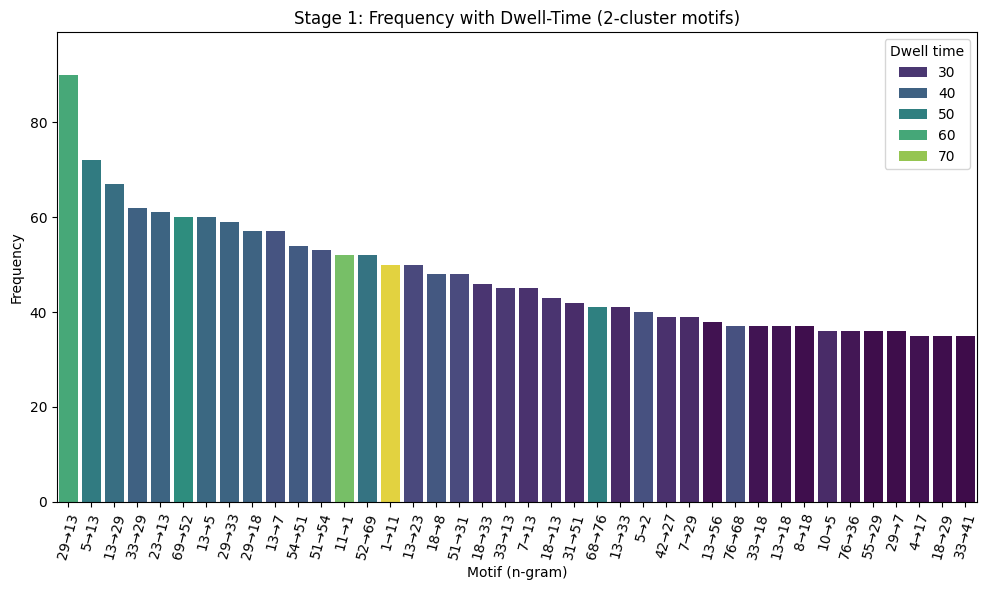

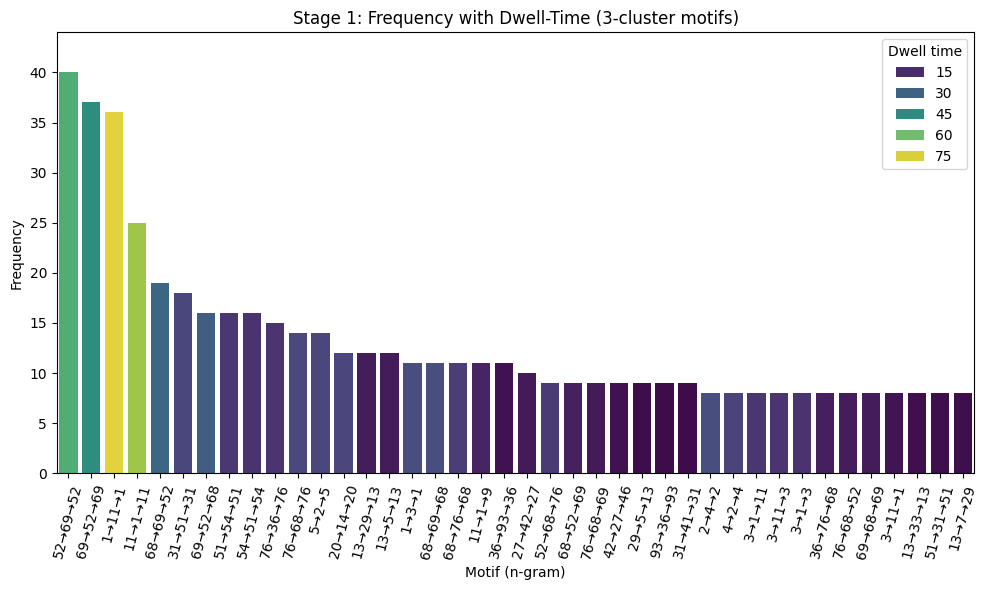

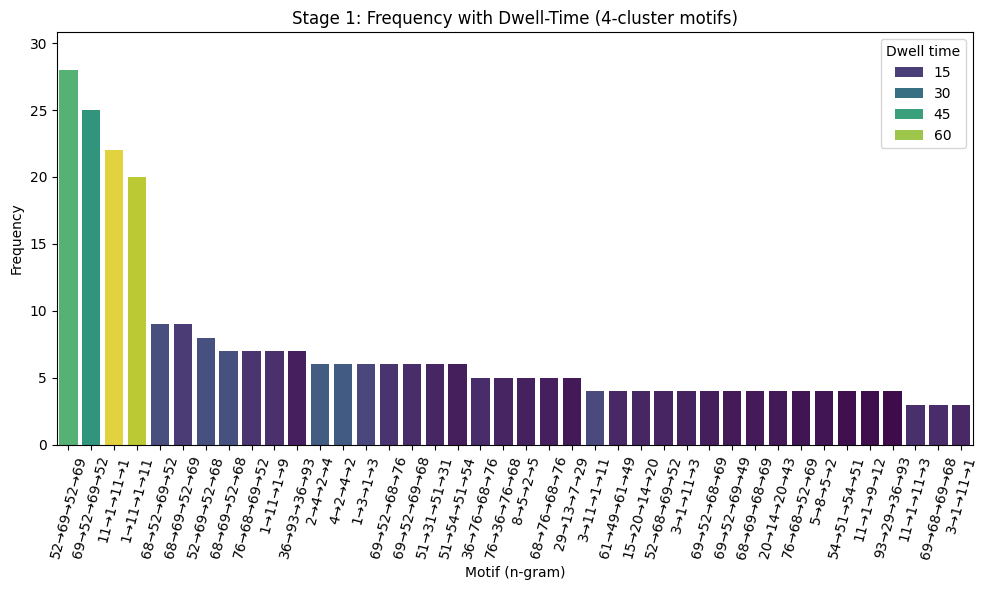

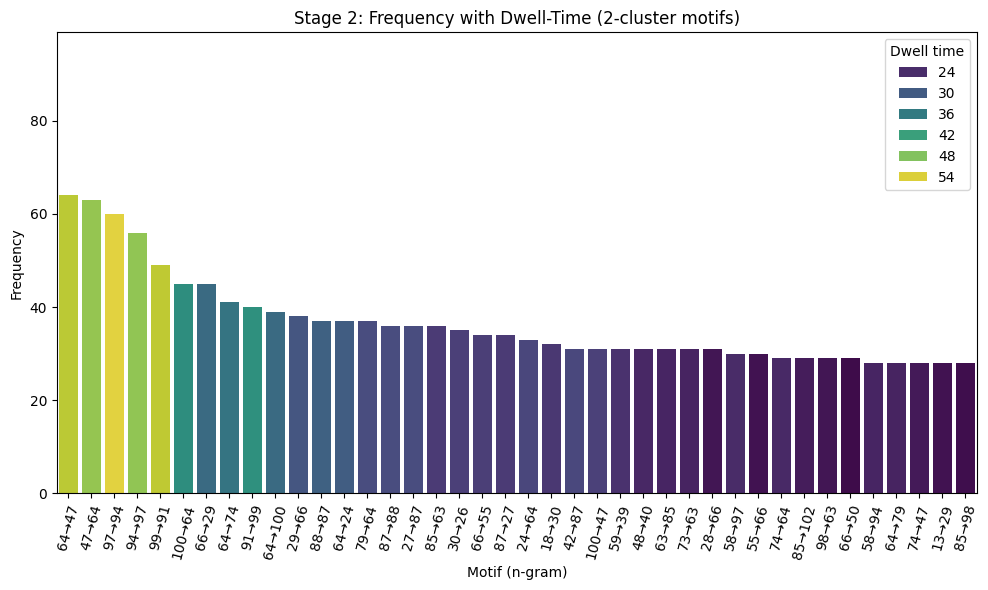

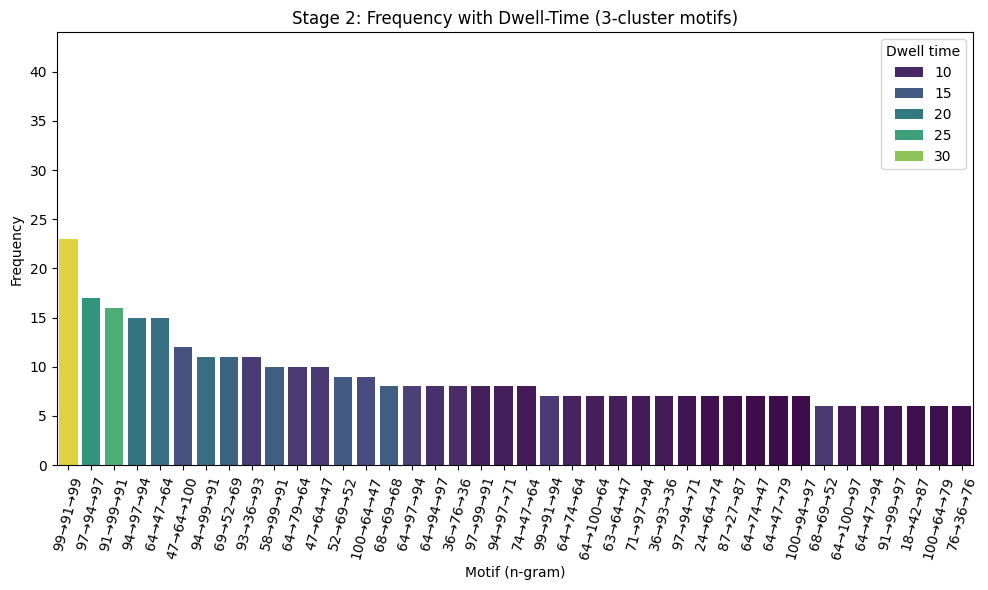

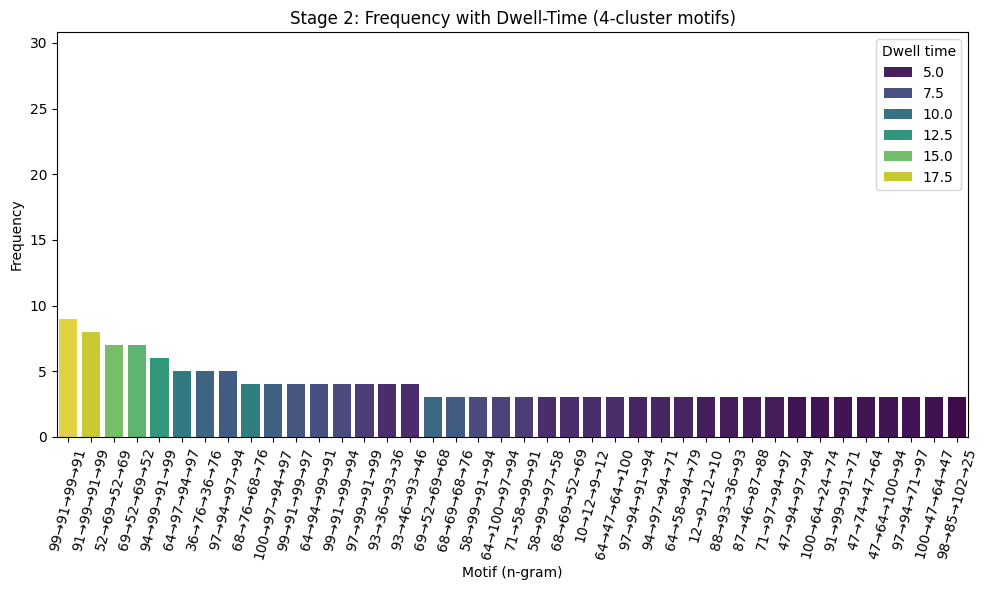

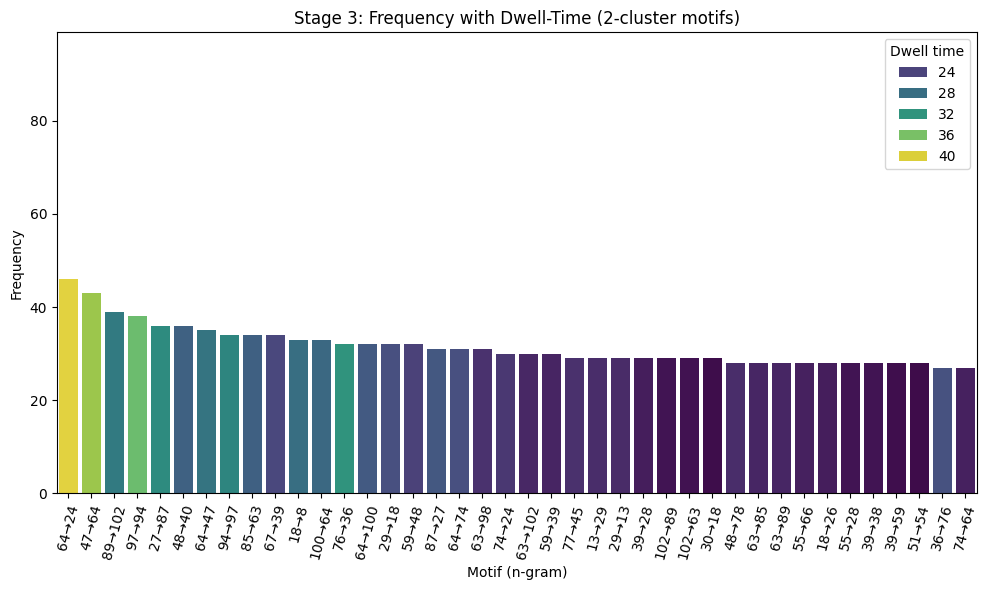

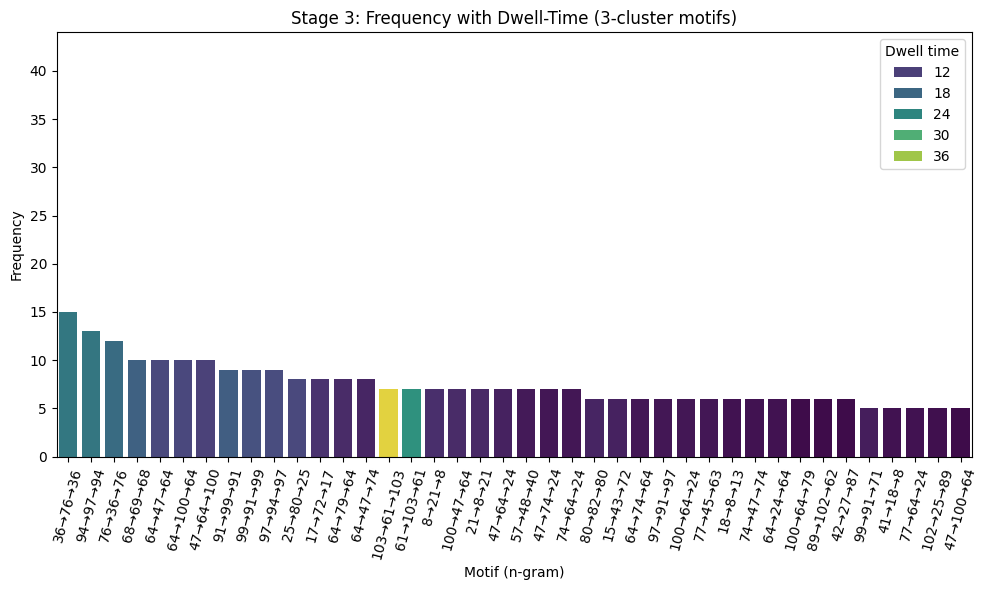

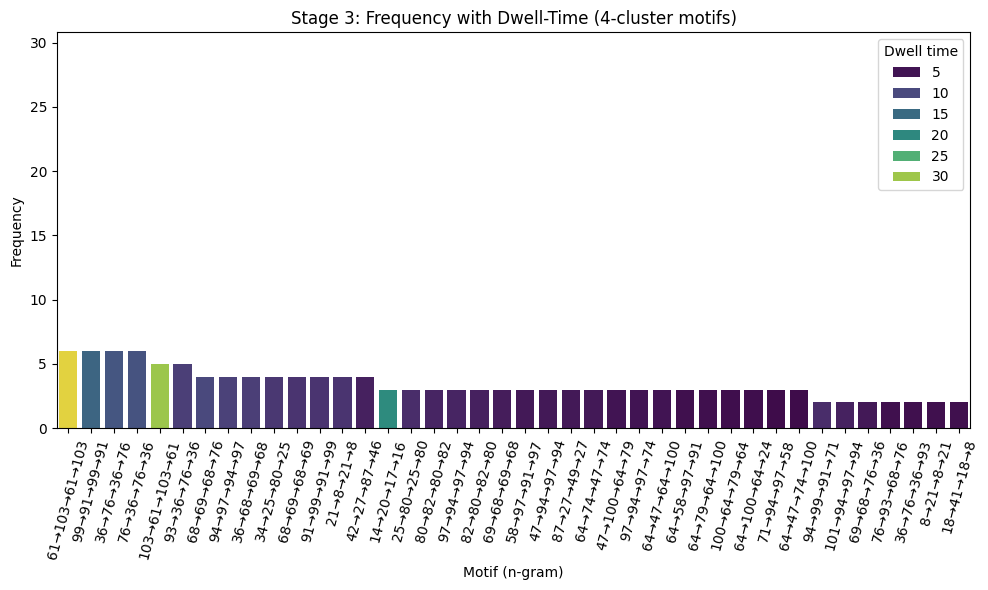

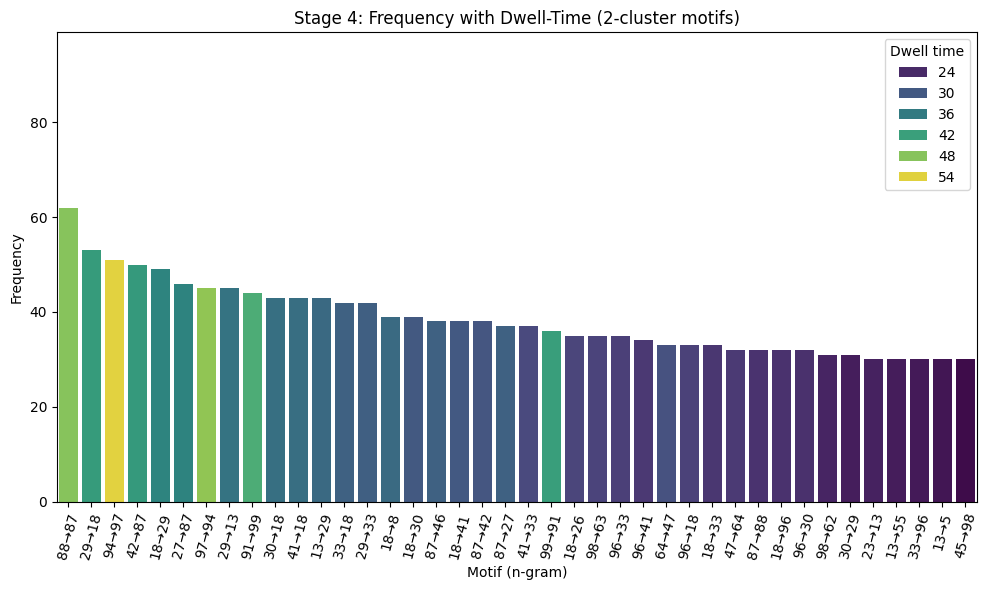

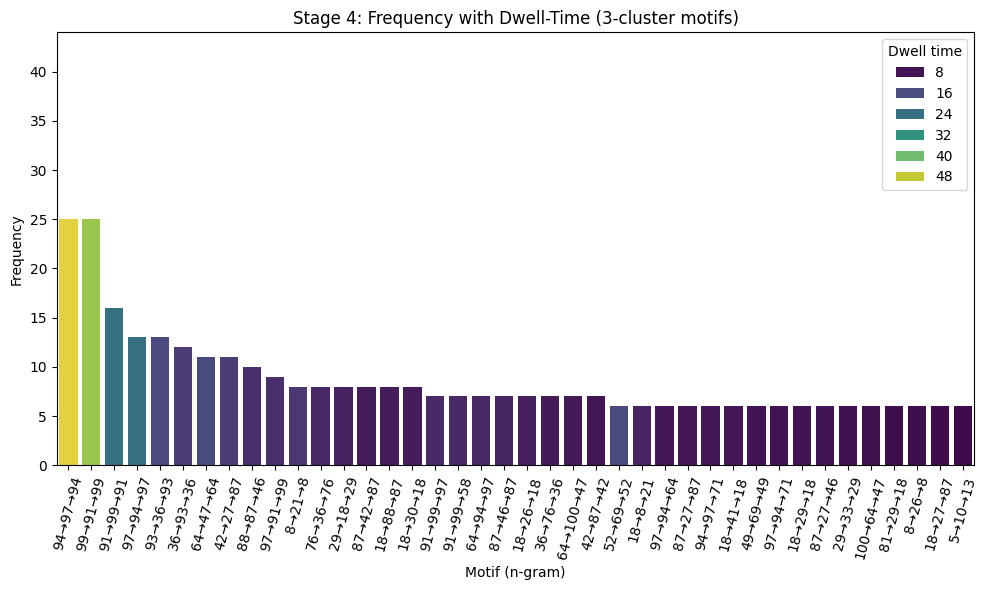

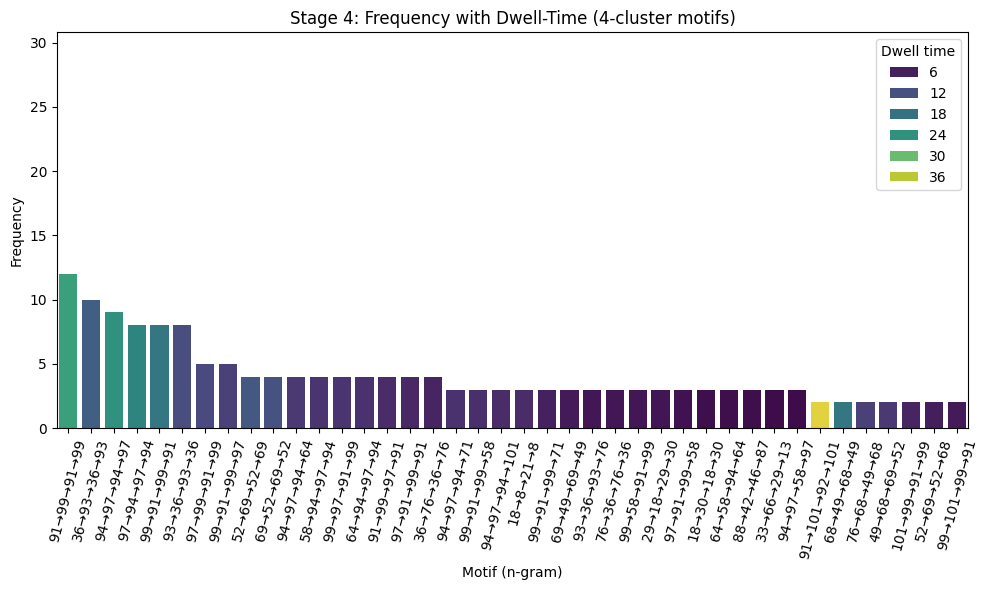

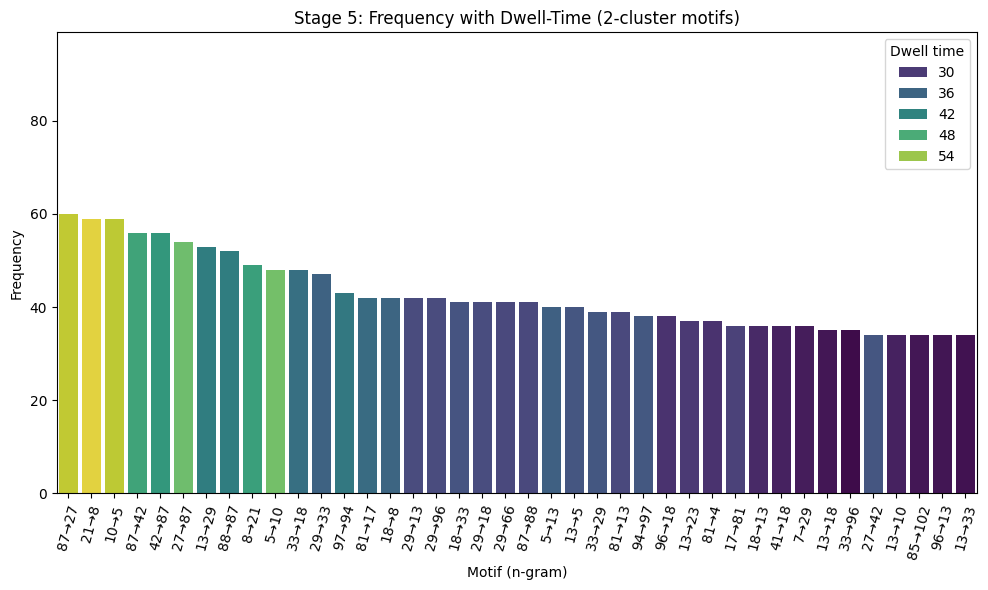

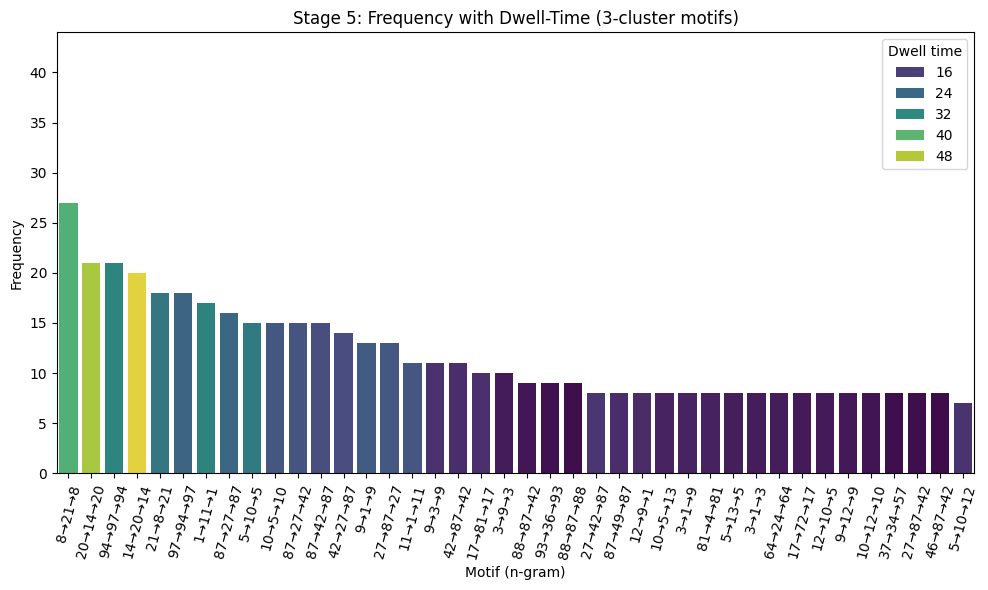

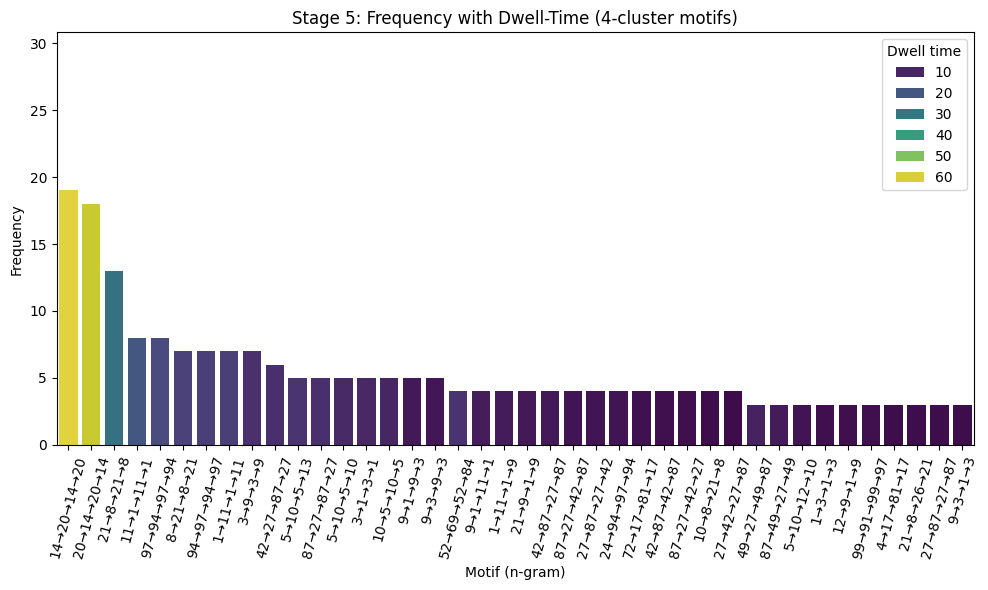

In [13]:
counter = 1
for label in sorted(df_sorted["label"].unique(), key=extract_week_number):
    for k in range(2, len(df_sorted["label"].unique()) + 1):
        subset = df_sorted[(df_sorted["motif_length"] == k) & (df_sorted["label"] == label)]
        if subset.empty:
            continue

        topk = subset.sort_values(primarySort, ascending=False).head(top_n)

        # Create a new figure for each plot
        plt.figure(figsize=(10, 6))
        sns.barplot(
            x="motif",
            y="frequency",
            hue="dwell_time_adj",
            #hue_norm=( motif_maxes[k]["dwell_min"], motif_maxes[k]["dwell_max"] ),
            data=topk,
            dodge=False,
            palette="viridis",
            errorbar=None
        )
        plt.ylim(0, motif_maxes[k]["y_max_sub"])

        plt.title(f"Stage {counter}: Frequency with Dwell-Time ({k}-cluster motifs)")
        plt.xlabel("Motif (n-gram)")
        plt.ylabel("Frequency")
        plt.xticks(rotation=75)
        plt.legend(title="Dwell time")

        plt.tight_layout()
        # Save each bar plot separately

        filename = os.path.join(motif_results_dir, f"{k}-gram", f"stage-{counter}_freq_vs_total-dwell.png")
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename, dpi=300)

        #plt.close()  # Close to avoid showing or overlapping plots

    counter += 1


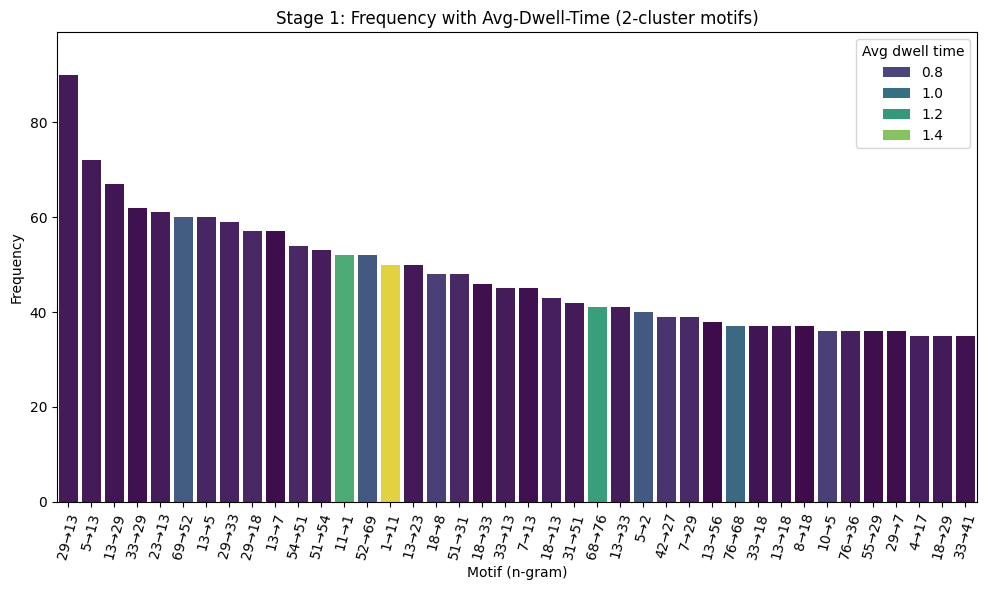

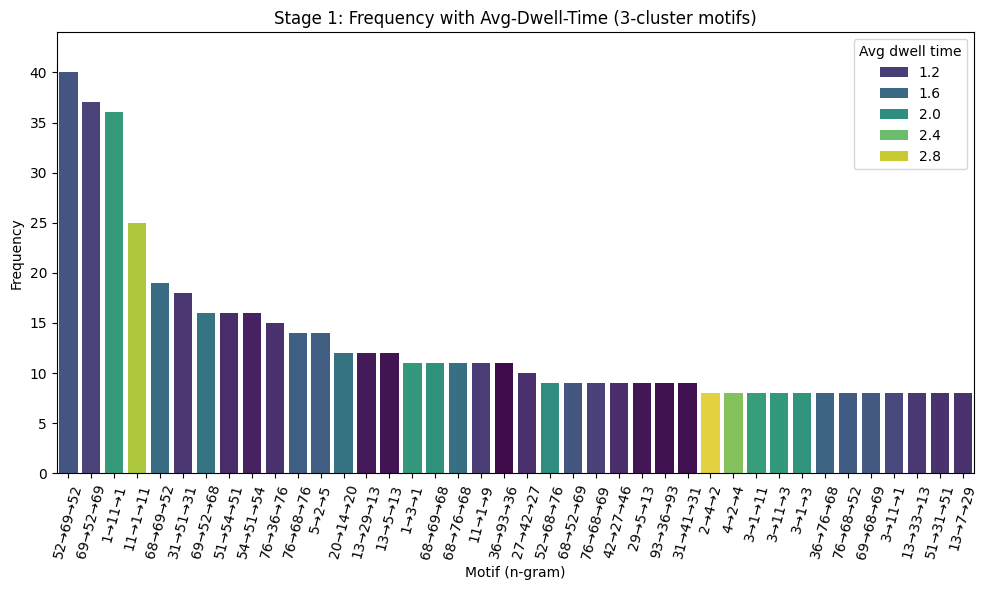

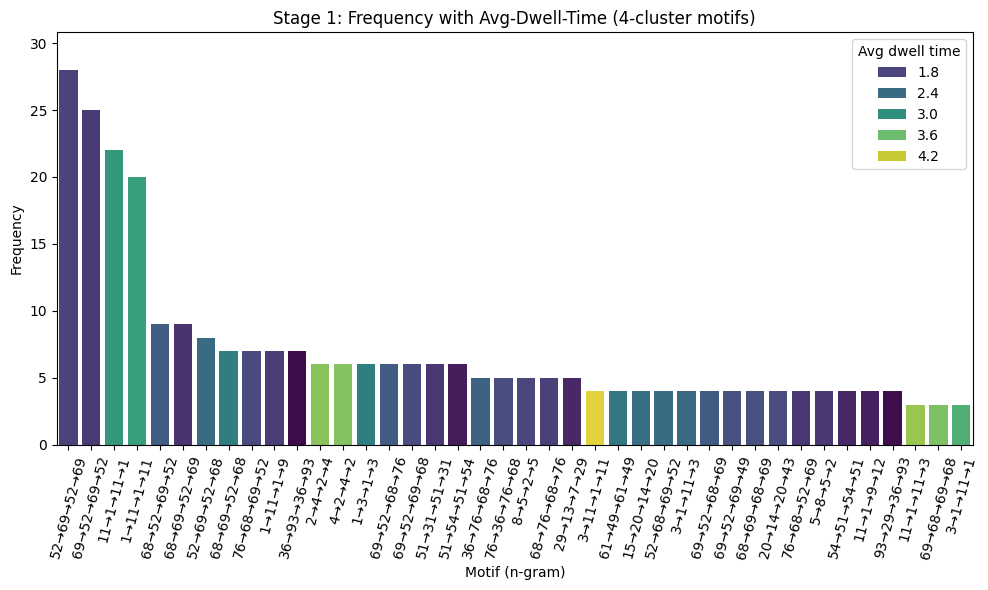

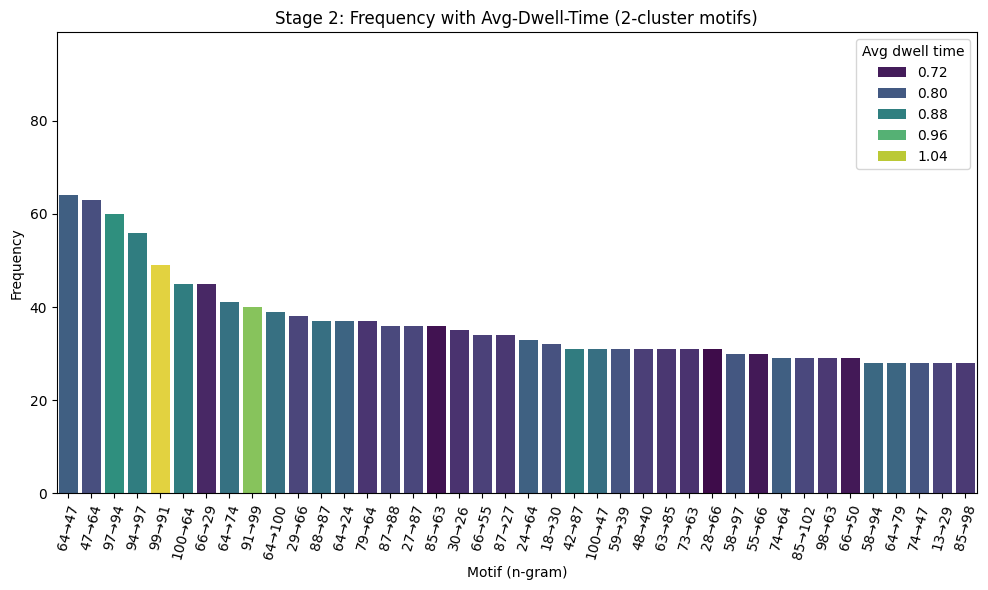

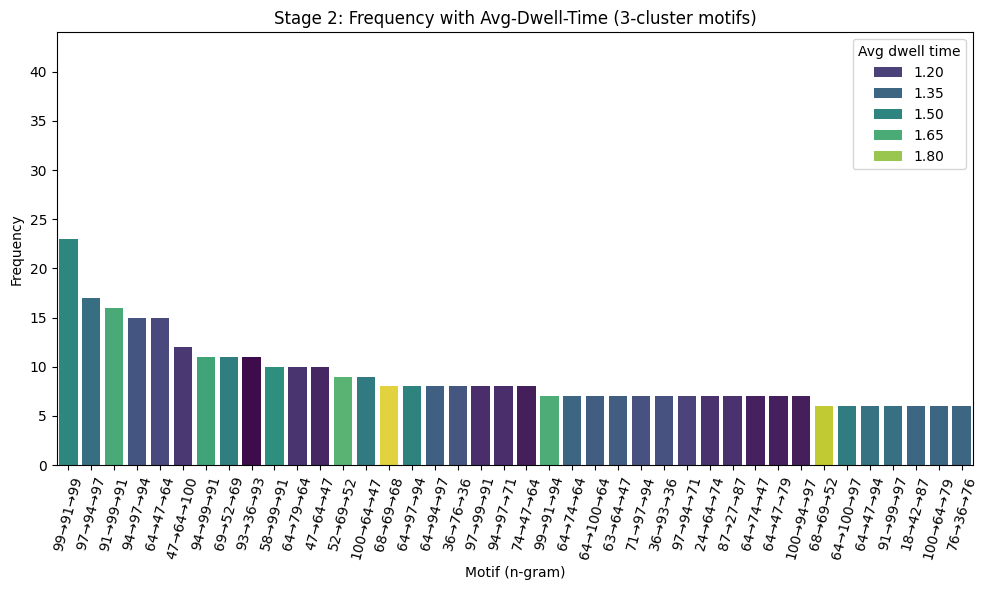

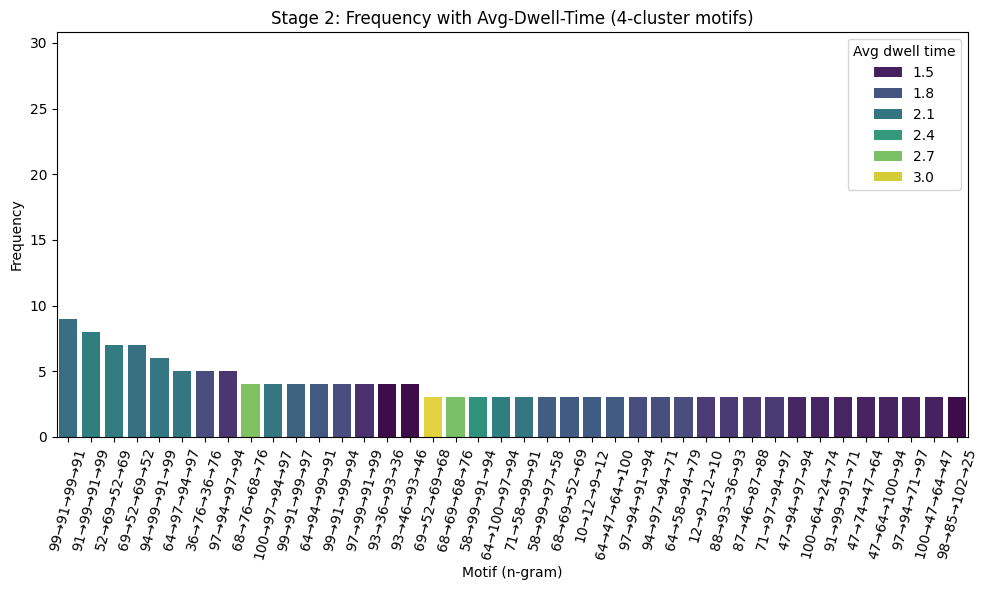

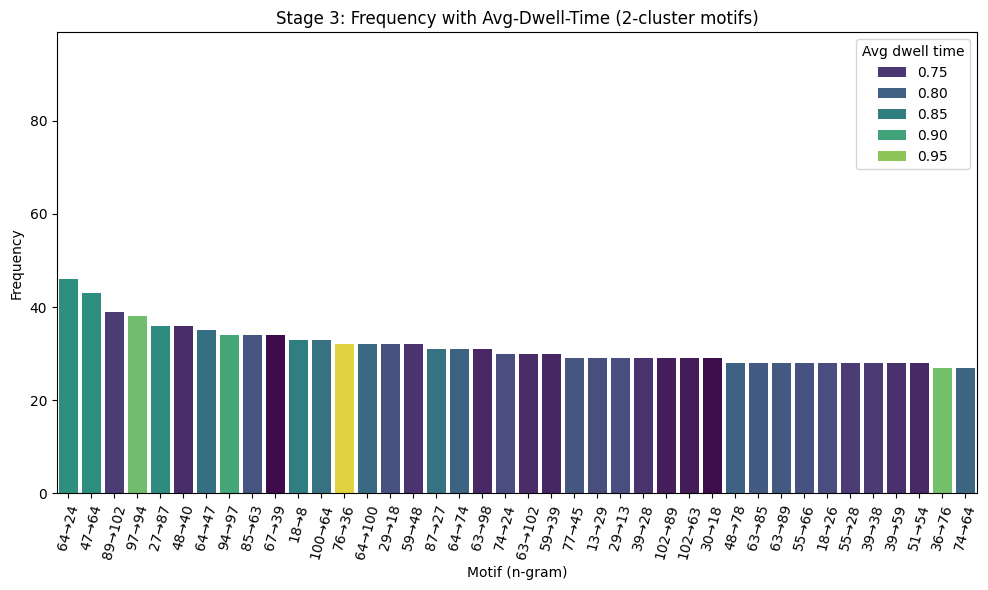

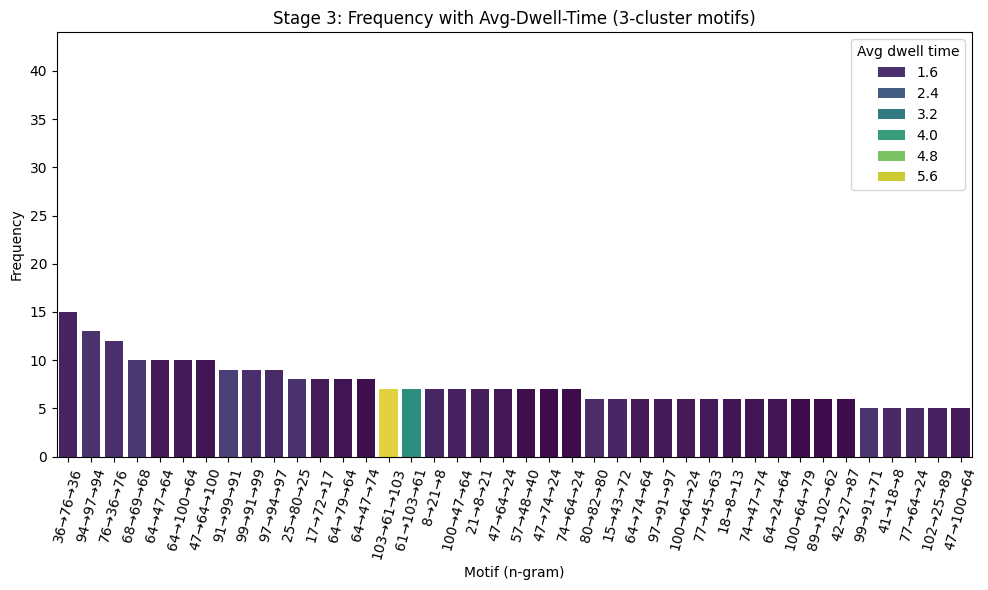

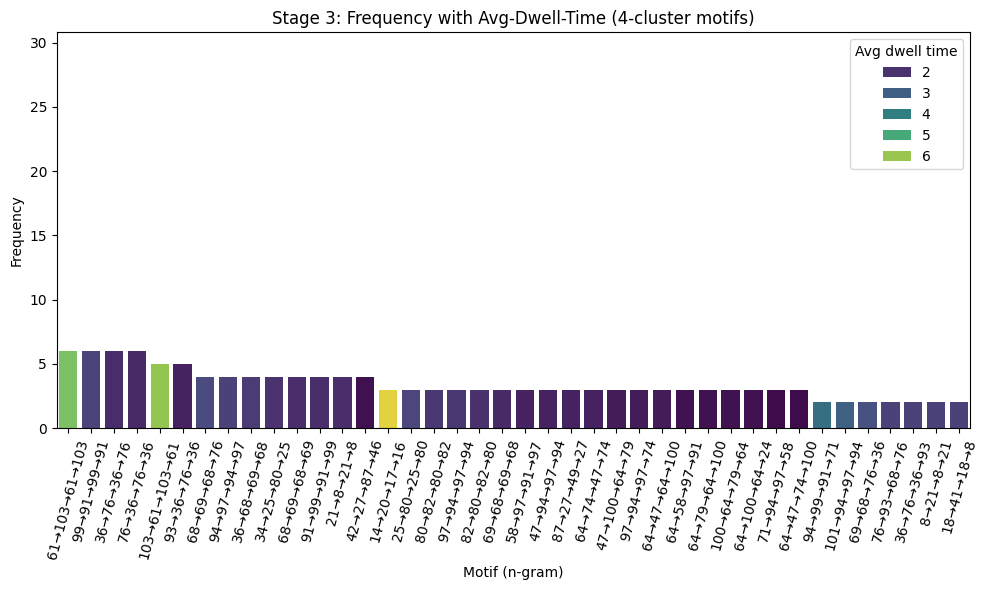

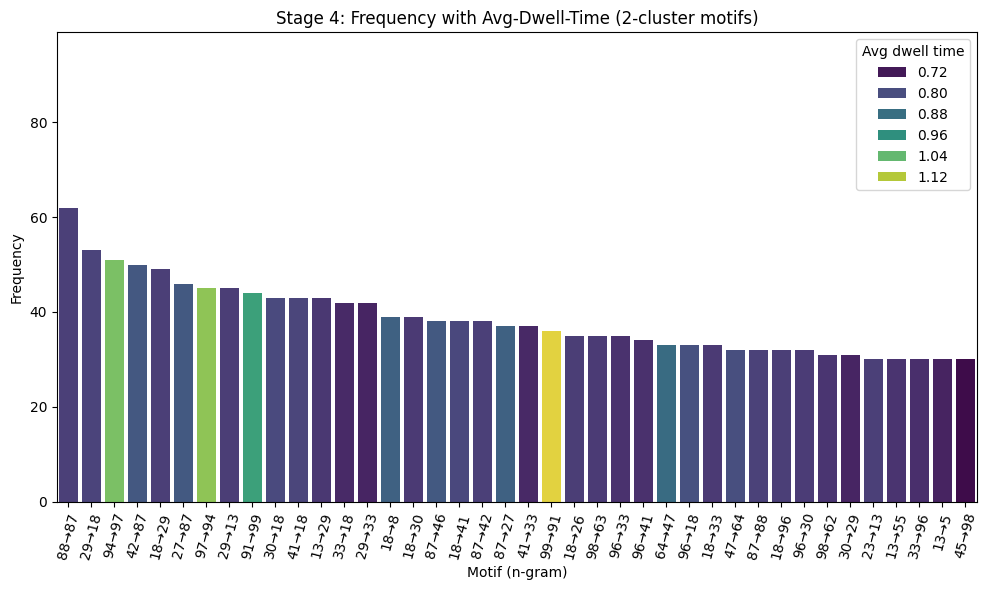

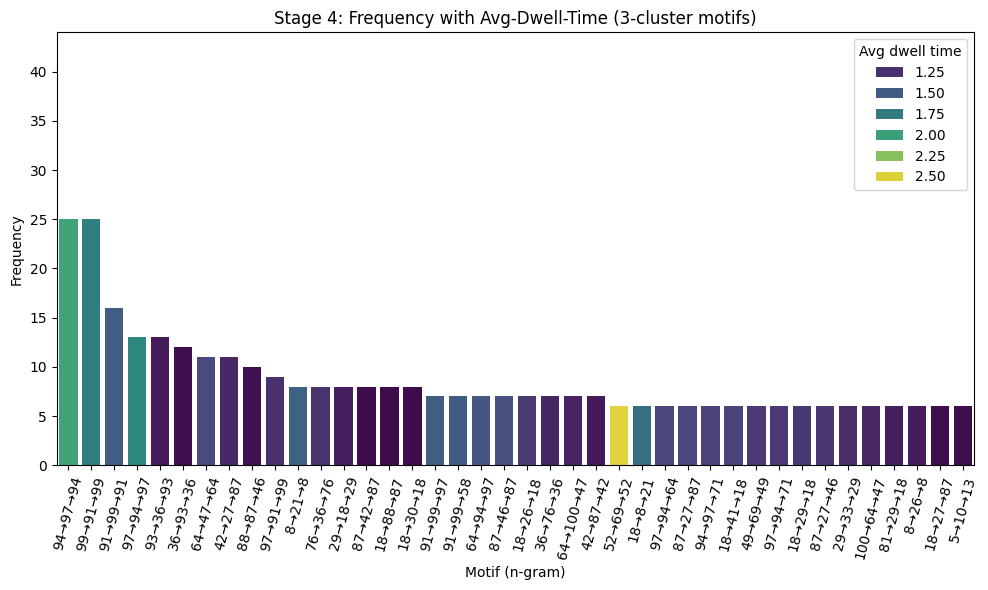

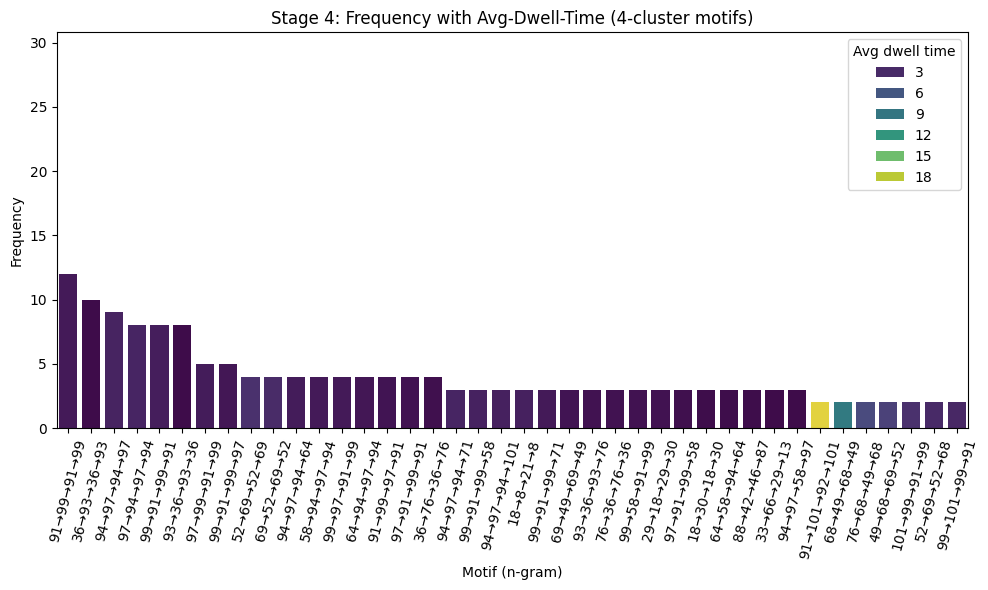

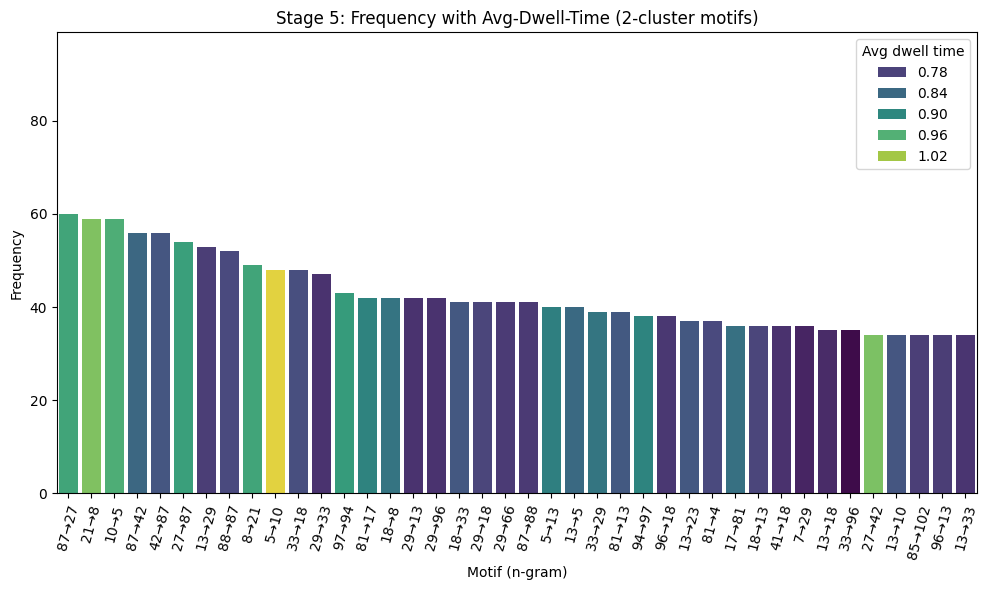

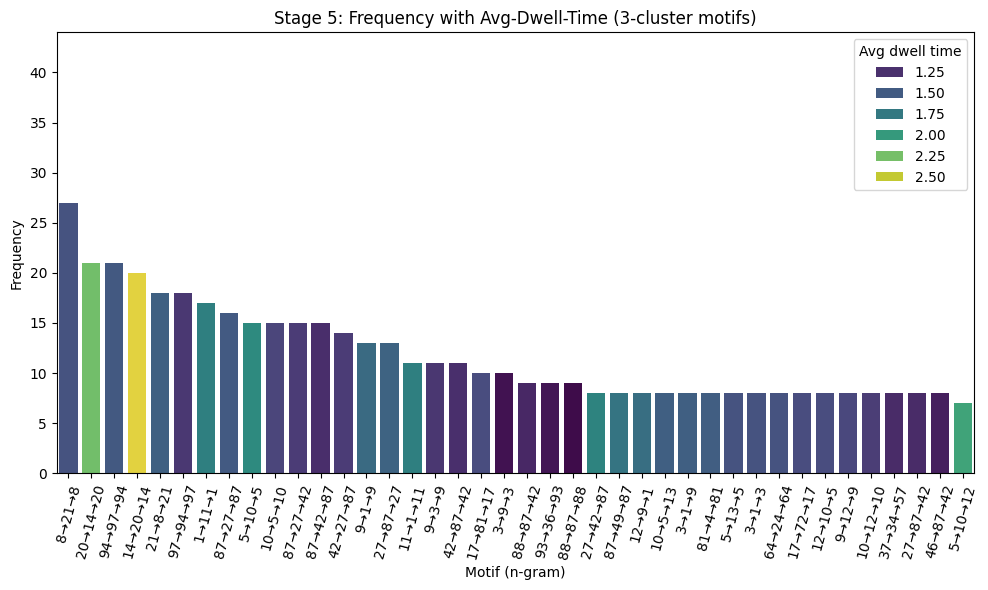

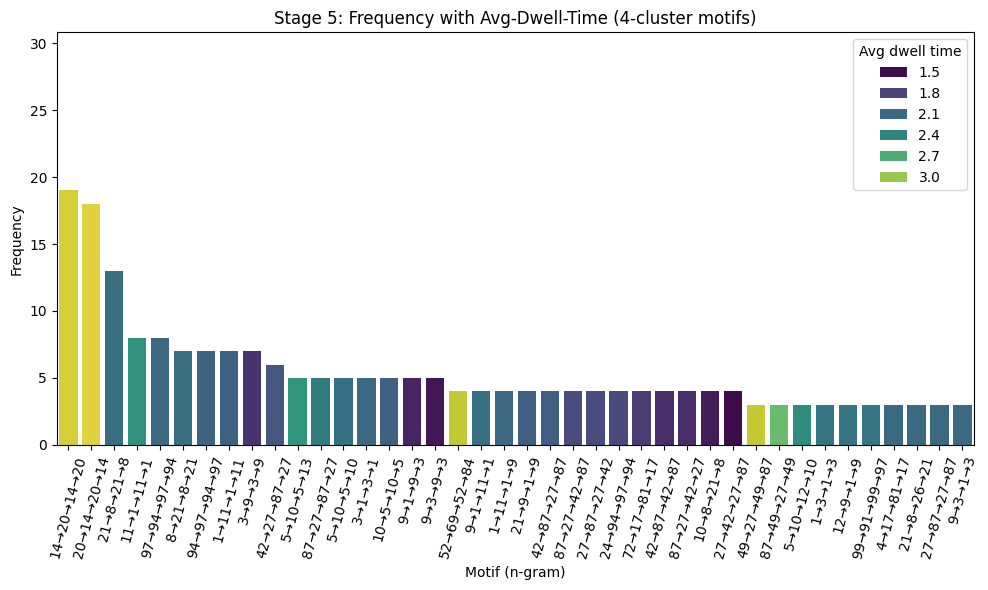

In [14]:


counter = 1
for label in sorted(df_sorted["label"].unique(), key=extract_week_number):
    for k in range(2, len(df_sorted["label"].unique()) + 1):
        subset = df_sorted[(df_sorted["motif_length"] == k) & (df_sorted["label"] == label)]
        if subset.empty:
            continue

        topk = subset.sort_values(primarySort, ascending=False).head(top_n)

        # Create a new figure for each plot
        plt.figure(figsize=(10, 6))
        sns.barplot(
            x="motif",
            y="frequency",
            hue="avg_dwell",
            data=topk,
            dodge=False,
            palette="viridis",
            errorbar=None
        )
        plt.ylim(0, motif_maxes[k]["y_max_sub"])

        plt.title(f"Stage {counter}: Frequency with Avg-Dwell-Time ({k}-cluster motifs)")
        plt.xlabel("Motif (n-gram)")
        plt.ylabel("Frequency")
        plt.xticks(rotation=75)
        plt.legend(title="Avg dwell time")

        plt.tight_layout()
        # Save each bar plot separately

        filename = os.path.join(motif_results_dir, f"{k}-gram", f"stage-{counter}_freq_vs_avg-dwell.png")
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename, dpi=300)

        #plt.close()  # Close to avoid showing or overlapping plots

    counter += 1


